# VIB Adversarial Robustness Across Image Datasets — ResNet-18, KL vs Rényi vs Tsallis, FGSM vs PGD

This notebook extends the original CIFAR-10 experiment into a **multi-dataset supervised image benchmark**. MNIST is intentionally not rerun here because it has already been completed separately.

### Datasets run by default

- **CIFAR-10** — 50k train / 10k test, RGB, 10 classes (existing baseline)
- **Fashion-MNIST** — 60k train / 10k test, grayscale, 10 classes
- **STL-10** — 5k labeled train / 8k test, RGB, 10 classes
- **Oxford-IIIT Pet** — trainval / test, RGB, 37 classes
- **DTD (Describable Textures Dataset)** — train+val / test, RGB, 47 texture classes

All datasets are resized to **32×32** so the computational cost and attack budget stay reasonably comparable to CIFAR-10. The underlying image content and dataset sizes still vary substantially.

For every selected dataset, the notebook runs:

**VIB × {KL, Rényi, Tsallis} × {clean, PGD adversarial training}**

and then evaluates every trained model under **FGSM and PGD** over the configured epsilon sweep. It also records training curves, information-theoretic metrics, beta calibration, per-dataset plots, cross-dataset comparison plots, CSV results, and model checkpoints.

The architecture remains a **CIFAR-style ResNet-18 with a VIB bottleneck**. It is made input-channel agnostic, but the default depth/width is deliberately kept fixed so the dataset is the main experimental variable rather than architecture. The existing adversarial-training sanity checks are retained.

## 1. Setup

In [1]:
import torch
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("WARNING: no GPU detected. Go to Runtime > Change runtime type > GPU, "
          "then Runtime > Restart and run all. Training will be very slow on CPU.")


PyTorch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [2]:
import os
import json
import time
import random

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

SEED = 42

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


## 2. Divergences — KL, Rényi, Tsallis

Ported verbatim from `divergences.py` in the source repo. All three are **exact closed-form Gaussian divergences** between the encoder posterior $q(z|x) = \mathcal{N}(\mu, \mathrm{diag}(\exp(\text{logvar})))$ and the standard-normal prior $p(z) = \mathcal{N}(0, I)$ — no Monte Carlo sampling is used, which keeps the training signal low-variance. Rényi and Tsallis both use $\alpha = 0.95 \in (0,1)$, the range in which the underlying Gaussian power integral is guaranteed finite for any positive-definite covariance (this is the same choice the source repo settled on).

Note: KL, Rényi(0.95) and Tsallis(0.95) are not on the same numeric scale — a given `beta` does not necessarily regularize all three equally strongly. The calibration sweep below reports this per divergence rather than assuming it away.

In [3]:
# =========================================================
# KL DIVERGENCE
# =========================================================

def kl_gaussian(mu, logvar):
    """Exact Gaussian KL divergence: KL(q(z|x) || p(z))."""
    var = torch.exp(logvar)
    kl = 0.5 * (mu.pow(2) + var - 1.0 - logvar)
    return kl.sum(dim=-1).mean()


# =========================================================
# EXACT GAUSSIAN POWER INTEGRAL  (shared by Renyi & Tsallis)
# =========================================================

def gaussian_log_integral_power(mu, logvar, alpha):
    """
    Exact Gaussian calculation of log A_alpha, where
        A_alpha = integral q(z)^alpha p(z)^(1-alpha) dz
    q(z) = N(mu, Sigma_q) diagonal, p(z) = N(0, I).
    Requires 0 < alpha < 1 (guarantees a finite integral for any
    positive-definite covariance). No Monte Carlo approximation.
    """
    if not (0.0 < alpha < 1.0):
        raise ValueError("Gaussian Renyi/Tsallis require 0 < alpha < 1.")

    alpha_t = torch.as_tensor(alpha, dtype=mu.dtype, device=mu.device)
    one_minus_alpha_t = torch.as_tensor(1.0 - alpha, dtype=mu.dtype, device=mu.device)

    logdet_sigma_q = logvar.sum(dim=-1)

    log_alpha = torch.log(alpha_t)
    log_one_minus_alpha = torch.log(one_minus_alpha_t)

    log_A_diagonal = torch.logaddexp(log_alpha - logvar, log_one_minus_alpha)
    logdet_A = log_A_diagonal.sum(dim=-1)

    log_denominator = torch.logaddexp(log_alpha, log_one_minus_alpha + logvar)
    denominator = torch.exp(log_denominator)

    mean_term = (-0.5 * alpha_t * one_minus_alpha_t * mu.pow(2) / denominator).sum(dim=-1)

    log_integral = (-0.5 * alpha_t * logdet_sigma_q) + (-0.5 * logdet_A) + mean_term
    return log_integral


# =========================================================
# RENYI DIVERGENCE
# =========================================================

def renyi_gaussian(mu, logvar, alpha=0.5):
    """Exact Gaussian Renyi divergence: D_R^alpha(q||p) = log(A_alpha) / (alpha - 1)."""
    if not (0.0 < alpha < 1.0):
        raise ValueError("Renyi training requires 0 < alpha < 1.")
    log_integral = gaussian_log_integral_power(mu, logvar, alpha)
    divergence = log_integral / (alpha - 1.0)
    return divergence.mean()


# =========================================================
# TSALLIS DIVERGENCE
# =========================================================

def tsallis_gaussian(mu, logvar, alpha=0.5):
    """Exact Gaussian Tsallis divergence: D_T^alpha(q||p) = (A_alpha - 1) / (alpha - 1)."""
    if not (0.0 < alpha < 1.0):
        raise ValueError("Tsallis training requires 0 < alpha < 1.")
    log_integral = gaussian_log_integral_power(mu, logvar, alpha)
    integral_minus_one = torch.expm1(log_integral)  # exp(log_integral) - 1, numerically stable
    divergence = integral_minus_one / (alpha - 1.0)
    return divergence.mean()


# =========================================================
# DIVERGENCE SELECTOR
# =========================================================

def divergence_loss(mu, logvar, divergence="kl", alpha=0.5):
    if divergence == "kl":
        return kl_gaussian(mu, logvar)
    elif divergence == "renyi":
        return renyi_gaussian(mu, logvar, alpha)
    elif divergence == "tsallis":
        return tsallis_gaussian(mu, logvar, alpha)
    else:
        raise ValueError(f"Unknown divergence: {divergence}")


## 3. Information-theoretic metrics

Ported verbatim from `entropy.py` and `information_metrics.py`. These estimate $I(X;Z)$ (via the KL term), $I(Z;Y) = H(Y) - H(Y|Z)$, and the IB objective $I(X;Z) - \beta I(Z;Y)$ for a trained model, so the three divergences can be compared not just on accuracy but on what they actually do to the bottleneck.

In [4]:
def shannon_entropy(probabilities):
    probabilities = probabilities[probabilities > 0]
    return -torch.sum(probabilities * torch.log(probabilities))


def renyi_entropy(probabilities, alpha=2.0):
    if alpha <= 0 or alpha == 1:
        raise ValueError("alpha must be > 0 and != 1")
    probabilities = probabilities[probabilities > 0]
    return (1 / (1 - alpha)) * torch.log(torch.sum(probabilities ** alpha))


def tsallis_entropy(probabilities, alpha=2.0):
    if alpha <= 0 or alpha == 1:
        raise ValueError("alpha must be > 0 and != 1")
    probabilities = probabilities[probabilities > 0]
    return (1 / (alpha - 1)) * (1 - torch.sum(probabilities ** alpha))


def calculate_i_xz(mu, logvar):
    var = torch.exp(logvar)
    kl_per_sample = 0.5 * (mu.pow(2) + var - 1.0 - logvar).sum(dim=-1)
    return kl_per_sample.mean().item()


def calculate_h_y(labels, num_classes):
    counts = torch.bincount(labels, minlength=num_classes).float()
    probabilities = counts / counts.sum()
    probabilities = probabilities[probabilities > 0]
    return -(probabilities * torch.log(probabilities)).sum().item()


def calculate_h_y_given_z(logits):
    probabilities = torch.softmax(logits, dim=-1)
    log_probabilities = torch.log(probabilities.clamp_min(1e-12))
    entropy_per_sample = -(probabilities * log_probabilities).sum(dim=-1)
    return entropy_per_sample.mean().item()


def calculate_i_zy(labels, logits, num_classes):
    """I(Z;Y) = H(Y) - H(Y|Z)"""
    h_y = calculate_h_y(labels, num_classes)
    h_y_given_z = calculate_h_y_given_z(logits)
    return {"H_Y": h_y, "H_Y_given_Z": h_y_given_z, "I_ZY": h_y - h_y_given_z}


def calculate_ib_objective(i_xz, i_zy, beta):
    """Information Bottleneck objective: I(X;Z) - beta * I(Z;Y)"""
    return i_xz - beta * i_zy


@torch.no_grad()
def calculate_all_information_metrics(model, loader, num_classes, beta, device, max_batches=20):
    """
    Average I(X;Z), H(Y), H(Y|Z), I(Z;Y) and the IB objective over
    up to `max_batches` batches of `loader` (deterministic mu / logvar,
    no reparameterization sampling).
    """
    model.eval()
    i_xz_vals, i_zy_vals, h_y_vals, h_y_given_z_vals = [], [], [], []

    for b, (images, labels) in enumerate(loader):
        if b >= max_batches:
            break
        images = images.to(device)
        labels = labels.to(device)

        mu, logvar = model.encode(images)
        logits = model.classifier(mu)

        i_xz_vals.append(calculate_i_xz(mu, logvar))
        zy = calculate_i_zy(labels, logits, num_classes)
        i_zy_vals.append(zy["I_ZY"])
        h_y_vals.append(zy["H_Y"])
        h_y_given_z_vals.append(zy["H_Y_given_Z"])

    i_xz = float(np.mean(i_xz_vals))
    i_zy = float(np.mean(i_zy_vals))
    h_y = float(np.mean(h_y_vals))
    h_y_given_z = float(np.mean(h_y_given_z_vals))
    ib_objective = calculate_ib_objective(i_xz, i_zy, beta)

    return {
        "I_XZ": i_xz,
        "H_Y": h_y,
        "H_Y_given_Z": h_y_given_z,
        "I_ZY": i_zy,
        "IB_objective": ib_objective,
    }


## 4. Adversarial attacks — FGSM & PGD

Ported from `adversarial_attacks.py`. Both attacks are **white-box** and use the **deterministic** encoder output (the mean $\mu$, no reparameterization noise) so the gradient signal used to craft the attack is not confounded by stochastic sampling. `evaluate_under_attack` runs a full attack sweep over a data loader and returns adversarial accuracy; it's called separately for FGSM and for PGD, at every epsilon, so the two attacks are always reported side by side rather than combined. These are the **evaluation-time** attacks (used only to measure robustness) — left as in the source repo.

The **training-time** generator (`generate_adversarial_batch`, used only if `"fgsm"` or `"pgd"` is in `CONFIG["training_modes"]`) has one deliberate change from the source repo: `_fgsm_inner_max` now starts from a **random point** in the epsilon-ball instead of the clean image, to avoid catastrophic overfitting in single-step adversarial training (see the note in Section 0).

In [5]:
# =========================================================
# FGSM ATTACK  (evaluation)
# =========================================================

def fgsm_attack(model, images, labels, epsilon, device, clamp_output=True):
    """Fast Gradient Sign Method: x' = x + epsilon * sign(grad_x L(f(x), y))."""
    images = images.clone().detach().to(device)
    labels = labels.clone().detach().to(device)
    images.requires_grad = True

    mu, logvar = model.encode(images)
    logits = model.classifier(mu)
    loss = F.cross_entropy(logits, labels)

    model.zero_grad()
    loss.backward()
    data_grad = images.grad.data

    adversarial_images = images.data + epsilon * data_grad.sign()

    if clamp_output:
        adversarial_images = torch.clamp(adversarial_images, 0.0, 1.0)

    return adversarial_images.detach()


# =========================================================
# PGD ATTACK  (evaluation)
# =========================================================

def pgd_attack(model, images, labels, epsilon, device, num_steps=20, step_size=None, clamp_output=True):
    """Projected Gradient Descent, multi-step, with random start."""
    if step_size is None:
        step_size = epsilon / 4.0

    original_images = images.clone().detach().to(device)
    labels = labels.clone().detach().to(device)

    adversarial_images = original_images + torch.empty_like(original_images).uniform_(-epsilon, epsilon)
    if clamp_output:
        adversarial_images = torch.clamp(adversarial_images, 0.0, 1.0)

    for _ in range(num_steps):
        adversarial_images = adversarial_images.clone().detach()
        adversarial_images.requires_grad = True

        mu, logvar = model.encode(adversarial_images)
        logits = model.classifier(mu)
        loss = F.cross_entropy(logits, labels)

        model.zero_grad()
        loss.backward()
        data_grad = adversarial_images.grad.data

        adversarial_images = adversarial_images.data + step_size * data_grad.sign()

        perturbation = torch.clamp(adversarial_images - original_images, -epsilon, epsilon)
        adversarial_images = original_images + perturbation

        if clamp_output:
            adversarial_images = torch.clamp(adversarial_images, 0.0, 1.0)

    return adversarial_images.detach()


# =========================================================
# EVALUATE UNDER ATTACK
# =========================================================

def evaluate_under_attack(model, attack_fn, test_loader, epsilon, device, clamp_output=True, **attack_kwargs):
    """Adversarial accuracy of `model` under `attack_fn` at a given epsilon."""
    model.eval()
    correct, total = 0, 0

    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        adversarial_images = attack_fn(model, images, labels, epsilon, device,
                                        clamp_output=clamp_output, **attack_kwargs)

        with torch.no_grad():
            mu, logvar = model.encode(adversarial_images)
            logits = model.classifier(mu)
            predictions = torch.argmax(logits, dim=1)
            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    return correct / total


# =========================================================
# TRAINING-TIME ADVERSARIAL BATCH GENERATION
#
#   - torch.autograd.grad(loss, delta_or_images) is used instead of
#     loss.backward(), so parameter .grad buffers are never touched
#     during crafting -- the optimizer step that follows only ever
#     sees gradients from the real training loss.
#   - model.eval() is set while crafting (so BatchNorm running stats
#     are not updated by these extra forward passes), then restored.
#   - FGSM training-time crafting uses a RANDOM START (unlike the
#     source repo) to avoid catastrophic overfitting.
# =========================================================

def _fgsm_inner_max(model, images, labels, epsilon, clamp_output=True):
    """One-step inner maximization (FGSM) with random start."""
    delta = torch.empty_like(images).uniform_(-epsilon, epsilon)
    delta.requires_grad_(True)

    mu, logvar = model.encode(images + delta)
    logits = model.classifier(mu)
    loss = F.cross_entropy(logits, labels)

    data_grad = torch.autograd.grad(loss, delta)[0]

    delta = delta.detach() + epsilon * data_grad.sign()
    delta = torch.clamp(delta, -epsilon, epsilon)

    adversarial_images = images + delta
    return torch.clamp(adversarial_images, 0.0, 1.0) if clamp_output else adversarial_images


def _pgd_inner_max(model, images, labels, epsilon, num_steps=5, step_size=None, clamp_output=True):
    """Multi-step inner maximization (PGD, random start)."""
    if step_size is None:
        step_size = epsilon / 4.0
    adversarial_images = images + torch.empty_like(images).uniform_(-epsilon, epsilon)
    if clamp_output:
        adversarial_images = torch.clamp(adversarial_images, 0.0, 1.0)
    for _ in range(num_steps):
        perturbed = adversarial_images.clone().detach()
        perturbed.requires_grad_(True)
        mu, logvar = model.encode(perturbed)
        logits = model.classifier(mu)
        loss = F.cross_entropy(logits, labels)
        data_grad = torch.autograd.grad(loss, perturbed)[0]
        adversarial_images = adversarial_images.detach() + step_size * data_grad.sign()
        perturbation = torch.clamp(adversarial_images - images, -epsilon, epsilon)
        adversarial_images = images + perturbation
        adversarial_images = torch.clamp(adversarial_images, 0.0, 1.0)
    return adversarial_images


def generate_adversarial_batch(model, images, labels, epsilon, device, method="fgsm",
                                num_steps=5, step_size=None, clamp_output=True):
    if method not in ("fgsm", "pgd"):
        raise ValueError(f"Unknown adversarial-training method: {method}.")
    was_training = model.training
    model.eval()
    try:
        images = images.clone().detach().to(device)
        labels = labels.clone().detach().to(device)
        if method == "fgsm":
            adversarial_images = _fgsm_inner_max(model, images, labels, epsilon, clamp_output)
        else:
            adversarial_images = _pgd_inner_max(model, images, labels, epsilon, num_steps, step_size, clamp_output)
    finally:
        if was_training:
            model.train()
    return adversarial_images.detach()


## 5. Model — input-agnostic VIB ResNet-18

The original model was written specifically for CIFAR-10. Here it is generalized to accept either grayscale or RGB images while retaining the same **ResNet-18 topology**: 3×3 stride-1 stem, no initial max-pool, four residual stages, global average pooling, then the VIB bottleneck.

An optional classifier dropout and base width are exposed in config, but the defaults keep the original model capacity. This is intentional: changing to a much larger ResNet/WideResNet would make architecture, rather than the dataset/divergence/adversarial-training regime, another major experimental variable.

In [6]:
def clamp_logvar(raw_logvar):
    """Numerical stability: keep exp(logvar) in a sane range."""
    return torch.clamp(raw_logvar, min=-8.0, max=8.0)


class VIBBase(nn.Module):
    """Shared reparameterization + forward logic for every VIB variant."""
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        logits = self.classifier(z)
        return logits, z, mu, logvar


class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_planes, planes, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_planes, planes, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(planes)
        self.conv2 = nn.Conv2d(planes, planes, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(planes)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_planes != planes * self.expansion:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_planes, planes * self.expansion, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(planes * self.expansion),
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        return F.relu(out)


class VIBResNet(VIBBase):
    """Generic CIFAR-style ResNet-18 encoder wrapped with a VIB bottleneck."""
    def __init__(self, input_shape=(3, 32, 32), hidden_dim=256, latent_dim=64,
                 num_classes=10, num_blocks=(2, 2, 2, 2), base_width=64,
                 classifier_dropout=0.0):
        super().__init__()
        in_channels = input_shape[0]
        self.base_width = base_width
        self.in_planes = base_width

        self.stem = nn.Sequential(
            nn.Conv2d(in_channels, base_width, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(base_width),
            nn.ReLU(inplace=True),
        )

        self.layer1 = self._make_layer(base_width, num_blocks[0], stride=1)
        self.layer2 = self._make_layer(base_width * 2, num_blocks[1], stride=2)
        self.layer3 = self._make_layer(base_width * 4, num_blocks[2], stride=2)
        self.layer4 = self._make_layer(base_width * 8, num_blocks[3], stride=2)
        self.gap = nn.AdaptiveAvgPool2d(1)

        final_width = base_width * 8
        self.fc_hidden = nn.Sequential(nn.Linear(final_width, hidden_dim), nn.ReLU())
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)

        classifier_layers = [nn.Linear(latent_dim, hidden_dim), nn.ReLU()]
        if classifier_dropout > 0:
            classifier_layers.append(nn.Dropout(classifier_dropout))
        classifier_layers.append(nn.Linear(hidden_dim, num_classes))
        self.classifier = nn.Sequential(*classifier_layers)

    def _make_layer(self, planes, blocks, stride):
        strides = [stride] + [1] * (blocks - 1)
        layers = []
        for s in strides:
            layers.append(BasicBlock(self.in_planes, planes, s))
            self.in_planes = planes * BasicBlock.expansion
        return nn.Sequential(*layers)

    def encode(self, x):
        h = self.stem(x)
        h = self.layer1(h)
        h = self.layer2(h)
        h = self.layer3(h)
        h = self.layer4(h)
        h = self.gap(h).flatten(1)
        h = self.fc_hidden(h)
        mu = self.fc_mu(h)
        logvar = clamp_logvar(self.fc_logvar(h))
        return mu, logvar


def build_vib_resnet(input_shape=(3, 32, 32), hidden_dim=256, latent_dim=64,
                     num_classes=10, base_width=64, classifier_dropout=0.0):
    return VIBResNet(
        input_shape=input_shape,
        hidden_dim=hidden_dim,
        latent_dim=latent_dim,
        num_classes=num_classes,
        base_width=base_width,
        classifier_dropout=classifier_dropout,
    )


# The default architecture stays equivalent in capacity/topology to the original CIFAR model.
_preview_model = build_vib_resnet()
n_params = sum(p.numel() for p in _preview_model.parameters())
print(f"VIB ResNet-18 parameter count (default RGB/10-class config): {n_params:,}")
del _preview_model


VIB ResNet-18 parameter count (default RGB/10-class config): 11,352,266


## 6. Config

The experiment is now dataset-driven. Every dataset gets its own inferred `num_classes` and `input_shape`, while the training/evaluation methodology remains shared.

`DATASETS_TO_RUN` controls the complete experiment. By default it includes CIFAR-10 plus the four new datasets; MNIST is intentionally excluded because it has already been run separately.

In [7]:
CONFIG = {
    # --- datasets ---
    "data_root": "./data",
    "datasets_to_run": ["cifar10", "fashionmnist", "stl10", "oxford_pet", "dtd"],
    "image_size": 32,

    # --- training ---
    "epochs": 20,
    "batch_size": 128,
    "learning_rate": 1e-3,
    "weight_decay": 0.0,
    "beta": None,                 # filled separately for each dataset by calibration
    "hidden_dim": 256,
    "latent_dim": 64,
    "base_width": 64,
    "classifier_dropout": 0.0,

    # --- divergences ---
    "divergences": ["kl", "renyi", "tsallis"],
    "renyi_alpha": 0.95,
    "tsallis_alpha": 0.95,

    # --- training regimes ---
    "training_modes": ["clean", "pgd"],
    "adv_train_epsilon": 8.0 / 255.0,
    "adv_train_pgd_steps": 5,
    "adv_train_epochs": None,

    # --- adversarial evaluation ---
    "attacks": ["fgsm", "pgd"],
    "epsilons": [0.02, 0.031, 0.05, 0.08, 0.12],
    "pgd_steps": 10,
    "pgd_step_size": None,

    # --- beta calibration ---
    "beta_candidates": [1e-5, 1e-4, 3e-4, 1e-3, 3e-3, 1e-2],
    "calibration_epochs": 5,
    "calibration_train_fraction": 0.25,
    "calibration_test_fraction": 0.5,
    "calibration_accuracy_tolerance": 0.03,

    # --- reproducibility / data loading ---
    "seed": SEED,
    "num_workers": 2,
}

print(json.dumps(CONFIG, indent=2, default=str))


{
  "data_root": "./data",
  "datasets_to_run": [
    "cifar10",
    "fashionmnist",
    "stl10",
    "oxford_pet",
    "dtd"
  ],
  "image_size": 32,
  "epochs": 20,
  "batch_size": 128,
  "learning_rate": 0.001,
  "weight_decay": 0.0,
  "beta": null,
  "hidden_dim": 256,
  "latent_dim": 64,
  "base_width": 64,
  "classifier_dropout": 0.0,
  "divergences": [
    "kl",
    "renyi",
    "tsallis"
  ],
  "renyi_alpha": 0.95,
  "tsallis_alpha": 0.95,
  "training_modes": [
    "clean",
    "pgd"
  ],
  "adv_train_epsilon": 0.03137254901960784,
  "adv_train_pgd_steps": 5,
  "adv_train_epochs": null,
  "attacks": [
    "fgsm",
    "pgd"
  ],
  "epsilons": [
    0.02,
    0.031,
    0.05,
    0.08,
    0.12
  ],
  "pgd_steps": 10,
  "pgd_step_size": null,
  "beta_candidates": [
    1e-05,
    0.0001,
    0.0003,
    0.001,
    0.003,
    0.01
  ],
  "calibration_epochs": 5,
  "calibration_train_fraction": 0.25,
  "calibration_test_fraction": 0.5,
  "calibration_accuracy_tolerance": 0.03,
  "s

## 7. Data — unified multi-dataset loader

All datasets are converted to tensors in the **[0, 1] pixel range**. No channel normalization is used because the adversarial attack code explicitly projects/clamps images in that same space.

For computational comparability, all images are resized/cropped to 32×32 before entering the same ResNet-18. Small datasets are kept at their full available labeled size; there is no artificial subsampling.

In [ ]:
DATA_ROOT = CONFIG["data_root"]
IMG_SIZE = CONFIG["image_size"]


def make_transforms(dataset_name):
    """Dataset-aware but attack-compatible transforms, all returning [0,1] tensors."""
    if dataset_name in ("cifar10", "fashionmnist"):
        channels = 3 if dataset_name == "cifar10" else 1
        train_ops = [
            transforms.Resize((IMG_SIZE, IMG_SIZE)),
            transforms.RandomCrop(IMG_SIZE, padding=4),
        ]
        if dataset_name == "cifar10":
            train_ops.append(transforms.RandomHorizontalFlip())
        train_ops.append(transforms.ToTensor())
        test_ops = [transforms.Resize((IMG_SIZE, IMG_SIZE)), transforms.ToTensor()]
        return transforms.Compose(train_ops), transforms.Compose(test_ops), channels

    # Natural-image datasets.
    train_transform = transforms.Compose([
        transforms.Resize((IMG_SIZE + 4, IMG_SIZE + 4)),
        transforms.RandomCrop(IMG_SIZE),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
    ])
    test_transform = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
    ])
    return train_transform, test_transform, 3


def build_dataset_pair(dataset_name, root=DATA_ROOT):
    """Return (train_dataset, test_dataset, metadata) for one supported dataset."""
    train_tf, test_tf, channels = make_transforms(dataset_name)

    if dataset_name == "cifar10":
        train_ds = datasets.CIFAR10(root=root, train=True, download=True, transform=train_tf)
        test_ds = datasets.CIFAR10(root=root, train=False, download=True, transform=test_tf)
        meta = {"display_name": "CIFAR-10", "num_classes": 10, "input_shape": (channels, IMG_SIZE, IMG_SIZE)}

    elif dataset_name == "fashionmnist":
        train_ds = datasets.FashionMNIST(root=root, train=True, download=True, transform=train_tf)
        test_ds = datasets.FashionMNIST(root=root, train=False, download=True, transform=test_tf)
        meta = {"display_name": "Fashion-MNIST", "num_classes": 10, "input_shape": (channels, IMG_SIZE, IMG_SIZE)}

    elif dataset_name == "stl10":
        train_ds = datasets.STL10(root=root, split="train", download=True, transform=train_tf)
        test_ds = datasets.STL10(root=root, split="test", download=True, transform=test_tf)
        meta = {"display_name": "STL-10", "num_classes": 10, "input_shape": (channels, IMG_SIZE, IMG_SIZE)}

    elif dataset_name == "oxford_pet":
        train_ds = datasets.OxfordIIITPet(root=root, split="trainval", target_types="category", download=True, transform=train_tf)
        test_ds = datasets.OxfordIIITPet(root=root, split="test", target_types="category", download=True, transform=test_tf)
        meta = {"display_name": "Oxford-IIIT Pet", "num_classes": 37, "input_shape": (channels, IMG_SIZE, IMG_SIZE)}

    elif dataset_name == "dtd":
        # Combine the official train + val partitions for supervised training; test stays untouched.
        dtd_train = datasets.DTD(root=root, split="train", partition=1, download=True, transform=train_tf)
        dtd_val = datasets.DTD(root=root, split="val", partition=1, download=True, transform=train_tf)
        train_ds = torch.utils.data.ConcatDataset([dtd_train, dtd_val])
        test_ds = datasets.DTD(root=root, split="test", partition=1, download=True, transform=test_tf)
        meta = {"display_name": "DTD", "num_classes": 47, "input_shape": (channels, IMG_SIZE, IMG_SIZE)}

    else:
        raise ValueError(f"Unsupported dataset: {dataset_name}")

    return train_ds, test_ds, meta


def make_loaders_for_dataset(dataset_name, cfg):
    train_ds, test_ds, meta = build_dataset_pair(dataset_name, cfg["data_root"])
    train_loader = DataLoader(
        train_ds, batch_size=cfg["batch_size"], shuffle=True,
        num_workers=cfg["num_workers"], drop_last=True, pin_memory=torch.cuda.is_available()
    )
    test_loader = DataLoader(
        test_ds, batch_size=cfg["batch_size"], shuffle=False,
        num_workers=cfg["num_workers"], pin_memory=torch.cuda.is_available()
    )
    return train_ds, test_ds, train_loader, test_loader, meta


dataset_bundle = {}
for dataset_name in CONFIG["datasets_to_run"]:
    print("=" * 75)
    print(f"Preparing {dataset_name} ...")
    bundle = make_loaders_for_dataset(dataset_name, CONFIG)
    dataset_bundle[dataset_name] = bundle
    train_ds, test_ds, train_loader, test_loader, meta = bundle
    print(f"{meta['display_name']}: train={len(train_ds):,} | test={len(test_ds):,} | "
          f"classes={meta['num_classes']} | input={meta['input_shape']} | train batches={len(train_loader):,}")


Preparing cifar10 ...


 51%|█████▏    | 87.7M/170M [13:05<12:46, 108kB/s]

## 8. Sanity checks — before spending GPU time

The same perturbation-bound and gradient-isolation checks are run on the **first configured dataset**. Because the attack code operates in [0,1] pixel space, this verifies that the generalized data/model path still satisfies the same adversarial-training invariants.

In [ ]:
_sanity_dataset = CONFIG["datasets_to_run"][0]
_, _, _sanity_train_loader, _, _sanity_meta = dataset_bundle[_sanity_dataset]
_sanity_model = build_vib_resnet(
    input_shape=_sanity_meta["input_shape"], hidden_dim=CONFIG["hidden_dim"],
    latent_dim=CONFIG["latent_dim"], num_classes=_sanity_meta["num_classes"],
    base_width=CONFIG["base_width"], classifier_dropout=CONFIG["classifier_dropout"],
).to(device)
_sanity_images, _sanity_labels = next(iter(_sanity_train_loader))
_sanity_images, _sanity_labels = _sanity_images.to(device), _sanity_labels.to(device)
_eps = CONFIG["adv_train_epsilon"]

print(f"Sanity-check dataset: {_sanity_meta['display_name']}")
print("--- Perturbation-bound check (L-infinity <= epsilon) ---")
for name, adv in [
    ("eval fgsm_attack", fgsm_attack(_sanity_model, _sanity_images, _sanity_labels, _eps, device)),
    ("eval pgd_attack", pgd_attack(_sanity_model, _sanity_images, _sanity_labels, _eps, device, num_steps=5)),
    ("train-time fgsm", generate_adversarial_batch(_sanity_model, _sanity_images, _sanity_labels, _eps, device, method="fgsm")),
    ("train-time pgd", generate_adversarial_batch(_sanity_model, _sanity_images, _sanity_labels, _eps, device, method="pgd", num_steps=5)),
]:
    linf = (adv - _sanity_images).abs().max().item()
    in_range = (adv.min().item() >= -1e-6) and (adv.max().item() <= 1.0 + 1e-6)
    status = "OK" if (linf <= _eps + 1e-5 and in_range) else "FAILED"
    print(f"[{status}] {name:18s} | max L-inf perturbation = {linf:.5f} | budget {_eps:.5f} | range={in_range}")

print("\n--- Gradient-isolation check ---")
_sanity_model.zero_grad()
assert all(p.grad is None for p in _sanity_model.parameters())
_ = generate_adversarial_batch(
    _sanity_model, _sanity_images, _sanity_labels, _eps, device, method="pgd", num_steps=5
)
leaked = [n for n, p in _sanity_model.named_parameters() if p.grad is not None]
print("[OK] no parameter gradients leaked during adversarial-example crafting." if not leaked else f"[FAILED] leaked gradients: {leaked[:5]}")
del _sanity_model, _sanity_images, _sanity_labels


## 9. Beta calibration — separately for each dataset

Because the three divergences are not numerically equivalent, beta is calibrated **per dataset** and then shared across the three divergences within that dataset. This keeps each dataset's full comparison internally fair without assuming one beta transfers unchanged across very different input distributions.

In [ ]:
def make_subset_loader(dataset, fraction, batch_size, shuffle, seed=SEED):
    if fraction >= 1.0:
        base = dataset
    else:
        n_keep = max(1, int(len(dataset) * fraction))
        g = torch.Generator().manual_seed(seed)
        idx = torch.randperm(len(dataset), generator=g)[:n_keep].tolist()
        base = Subset(dataset, idx)
    return DataLoader(
        base, batch_size=batch_size, shuffle=shuffle,
        num_workers=CONFIG["num_workers"], drop_last=shuffle
    )


@torch.no_grad()
def evaluate_clean(model, loader, device):
    model.eval()
    correct, total = 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        mu, logvar = model.encode(images)
        logits = model.classifier(mu)
        preds = torch.argmax(logits, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    return correct / total


def calibration_run(divergence, beta, cfg, meta, calib_train_loader, calib_test_loader):
    set_seed(cfg["seed"])
    model = build_vib_resnet(
        input_shape=meta["input_shape"], hidden_dim=cfg["hidden_dim"],
        latent_dim=cfg["latent_dim"], num_classes=meta["num_classes"],
        base_width=cfg["base_width"], classifier_dropout=cfg["classifier_dropout"],
    ).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=cfg["learning_rate"], weight_decay=cfg["weight_decay"])
    alpha = cfg["renyi_alpha"] if divergence == "renyi" else (cfg["tsallis_alpha"] if divergence == "tsallis" else 0.5)

    for _ in range(cfg["calibration_epochs"]):
        model.train()
        for images, labels in calib_train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            logits, z, mu, logvar = model(images)
            ce_loss = F.cross_entropy(logits, labels)
            div_loss = divergence_loss(mu, logvar, divergence=divergence, alpha=alpha)
            (ce_loss + beta * div_loss).backward()
            optimizer.step()

    clean_acc = evaluate_clean(model, calib_test_loader, device)
    info = calculate_all_information_metrics(
        model, calib_test_loader, meta["num_classes"], beta, device, max_batches=10
    )
    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return clean_acc, info["I_XZ"]


calib_frames = []
beta_by_dataset = {}
calib_start_all = time.time()

for dataset_name in CONFIG["datasets_to_run"]:
    train_ds, test_ds, train_loader, test_loader, meta = dataset_bundle[dataset_name]
    calib_train_loader = make_subset_loader(
        train_ds, CONFIG["calibration_train_fraction"], CONFIG["batch_size"], shuffle=True, seed=CONFIG["seed"]
    )
    calib_test_loader = make_subset_loader(
        test_ds, CONFIG["calibration_test_fraction"], CONFIG["batch_size"], shuffle=False, seed=CONFIG["seed"]
    )

    print("=" * 80)
    print(f"Beta calibration — {meta['display_name']}")
    rows = []
    for div in CONFIG["divergences"]:
        for beta in CONFIG["beta_candidates"]:
            t0 = time.time()
            acc, i_xz = calibration_run(div, beta, CONFIG, meta, calib_train_loader, calib_test_loader)
            dt = time.time() - t0
            print(f"[{div:7s}] beta={beta:.0e} | clean acc={acc:.4f} | I(X;Z)={i_xz:8.2f} | {dt:.0f}s")
            rows.append({
                "dataset": dataset_name, "dataset_display": meta["display_name"],
                "divergence": div, "beta": beta, "clean_acc": acc, "I_XZ": i_xz
            })
    calib_frames.append(pd.DataFrame(rows))

    calib_df_ds = calib_frames[-1]
    tol = CONFIG["calibration_accuracy_tolerance"]
    recommended = {}
    for div in CONFIG["divergences"]:
        sub = calib_df_ds[calib_df_ds["divergence"] == div].sort_values("beta")
        best_acc = sub["clean_acc"].max()
        acceptable = sub[sub["clean_acc"] >= best_acc - tol]
        recommended[div] = acceptable["beta"].max()
    beta_by_dataset[dataset_name] = float(min(recommended.values()))
    print(f"Selected shared beta for {meta['display_name']}: {beta_by_dataset[dataset_name]:.0e}")

calib_df = pd.concat(calib_frames, ignore_index=True)
print(f"\nTotal calibration time: {(time.time() - calib_start_all) / 60:.1f} min")
print(pd.DataFrame([{"dataset": k, "dataset_display": dataset_bundle[k][4]["display_name"], "selected_beta": v} for k, v in beta_by_dataset.items()]))


Beta calibration — CIFAR-10
[kl     ] beta=1e-05 | clean acc=0.4996 | I(X;Z)=  176.04 | 50s
[kl     ] beta=1e-04 | clean acc=0.4940 | I(X;Z)=  123.94 | 51s
[kl     ] beta=3e-04 | clean acc=0.4804 | I(X;Z)=   68.86 | 53s
[kl     ] beta=1e-03 | clean acc=0.4726 | I(X;Z)=   40.74 | 53s
[kl     ] beta=3e-03 | clean acc=0.5032 | I(X;Z)=   23.57 | 53s
[kl     ] beta=1e-02 | clean acc=0.5060 | I(X;Z)=   11.49 | 53s
[renyi  ] beta=1e-05 | clean acc=0.5054 | I(X;Z)=  209.69 | 54s
[renyi  ] beta=1e-04 | clean acc=0.4686 | I(X;Z)=  105.57 | 54s
[renyi  ] beta=3e-04 | clean acc=0.5032 | I(X;Z)=   78.71 | 55s
[renyi  ] beta=1e-03 | clean acc=0.4830 | I(X;Z)=   43.45 | 54s
[renyi  ] beta=3e-03 | clean acc=0.4880 | I(X;Z)=   23.61 | 54s
[renyi  ] beta=1e-02 | clean acc=0.4822 | I(X;Z)=   10.30 | 54s
[tsallis] beta=1e-05 | clean acc=0.4566 | I(X;Z)=  250.39 | 54s
[tsallis] beta=1e-04 | clean acc=0.4782 | I(X;Z)=  222.01 | 54s
[tsallis] beta=3e-04 | clean acc=0.4750 | I(X;Z)=  229.07 | 54s
[tsallis] be

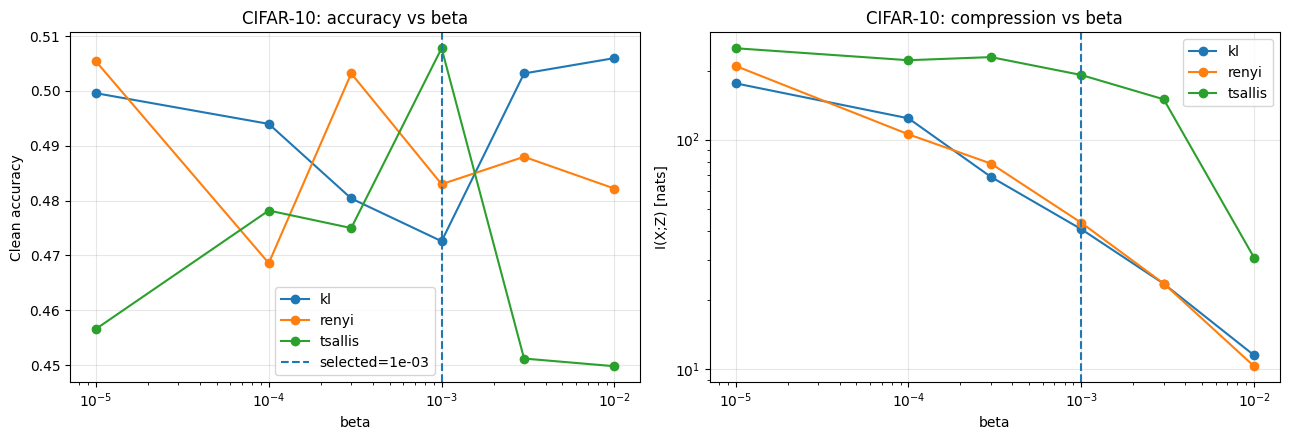

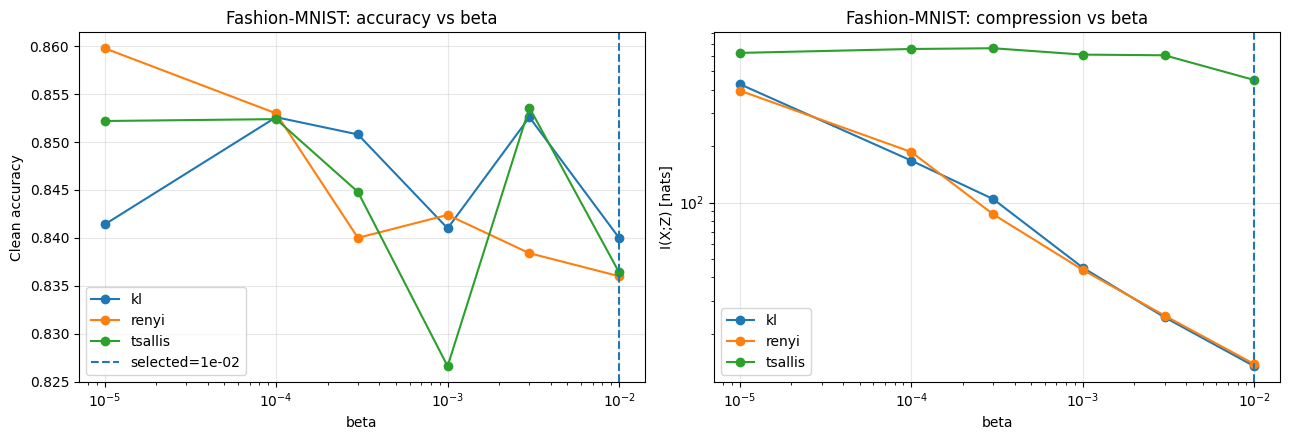

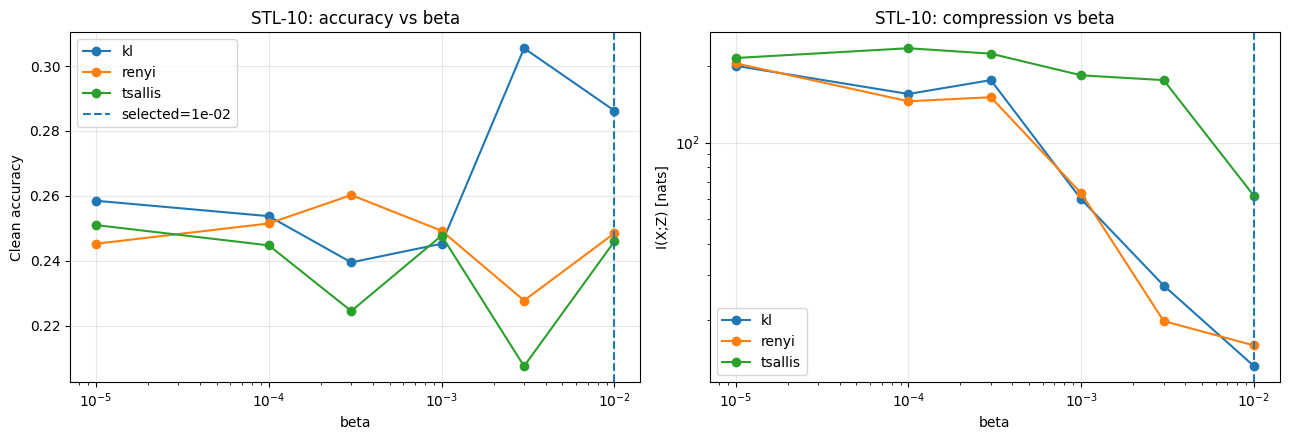

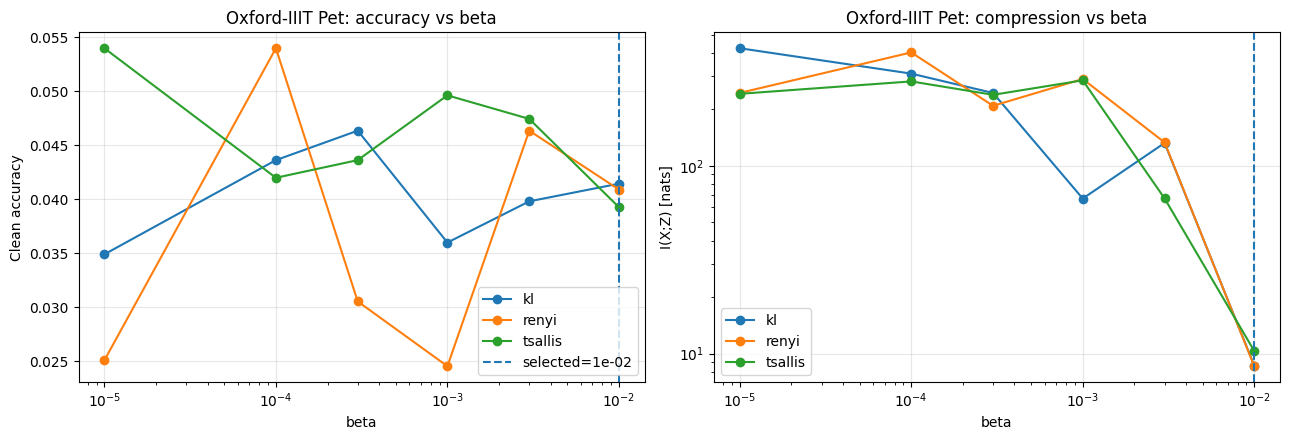

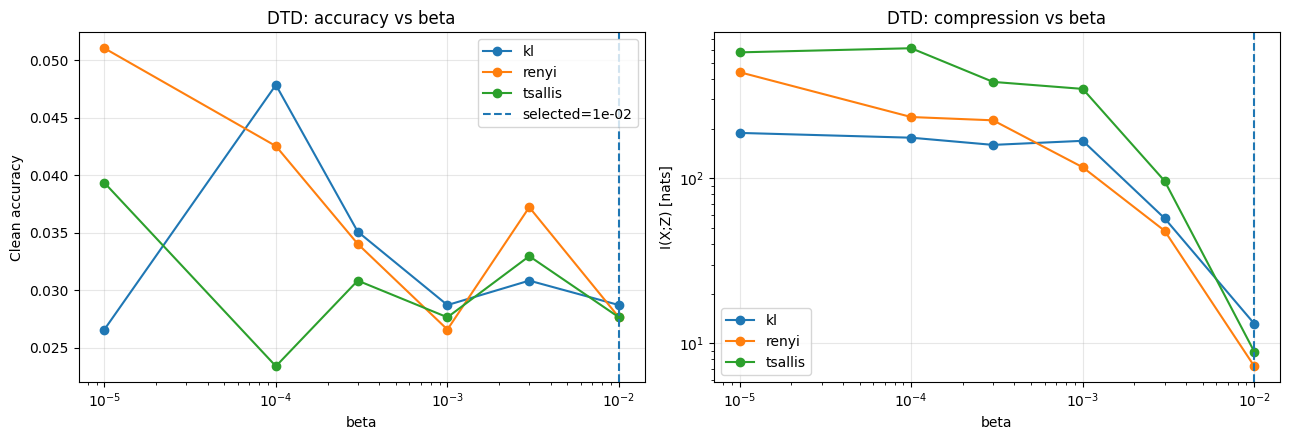

In [ ]:
# Per-dataset calibration plots
for dataset_name in CONFIG["datasets_to_run"]:
    meta = dataset_bundle[dataset_name][4]
    sub_df = calib_df[calib_df["dataset"] == dataset_name]
    selected_beta = beta_by_dataset[dataset_name]
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    for div in CONFIG["divergences"]:
        sub = sub_df[sub_df["divergence"] == div].sort_values("beta")
        axes[0].plot(sub["beta"], sub["clean_acc"], marker="o", label=div)
        axes[1].plot(sub["beta"], sub["I_XZ"], marker="o", label=div)
    axes[0].set_xscale("log"); axes[0].set_xlabel("beta"); axes[0].set_ylabel("Clean accuracy")
    axes[0].set_title(f"{meta['display_name']}: accuracy vs beta")
    axes[0].axvline(selected_beta, linestyle="--", label=f"selected={selected_beta:.0e}")
    axes[0].grid(alpha=0.3); axes[0].legend()
    axes[1].set_xscale("log"); axes[1].set_yscale("log"); axes[1].set_xlabel("beta"); axes[1].set_ylabel("I(X;Z) [nats]")
    axes[1].set_title(f"{meta['display_name']}: compression vs beta")
    axes[1].axvline(selected_beta, linestyle="--"); axes[1].grid(alpha=0.3); axes[1].legend()
    plt.tight_layout(); plt.show()


## 10. Training

`train_vib_model` is the original training logic generalized to dataset metadata. In PGD mode, every batch is replaced by a random-start PGD adversarial version before the real VIB loss is backpropagated. The model architecture, VIB objective, and adversarial-training procedure are otherwise unchanged.

In [ ]:
def train_vib_model(dataset_name, divergence, training_mode, cfg, train_loader, test_loader, meta, device, verbose=True):
    set_seed(cfg["seed"])

    model = build_vib_resnet(
        input_shape=meta["input_shape"],
        hidden_dim=cfg["hidden_dim"],
        latent_dim=cfg["latent_dim"],
        num_classes=meta["num_classes"],
        base_width=cfg["base_width"],
        classifier_dropout=cfg["classifier_dropout"],
    ).to(device)

    beta = beta_by_dataset[dataset_name]
    epochs = cfg["adv_train_epochs"] if (training_mode != "clean" and cfg["adv_train_epochs"]) else cfg["epochs"]
    optimizer = torch.optim.AdamW(model.parameters(), lr=cfg["learning_rate"], weight_decay=cfg["weight_decay"])
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    if divergence == "renyi":
        alpha = cfg["renyi_alpha"]
    elif divergence == "tsallis":
        alpha = cfg["tsallis_alpha"]
    else:
        alpha = 0.5

    history = []
    start = time.time()

    for epoch in range(epochs):
        model.train()
        total_loss = total_ce = total_div = 0.0
        robust_correct = robust_total = 0
        n_batches = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            if training_mode != "clean":
                images = generate_adversarial_batch(
                    model, images, labels, cfg["adv_train_epsilon"], device,
                    method=training_mode, num_steps=cfg["adv_train_pgd_steps"], clamp_output=True,
                )

            optimizer.zero_grad()
            logits, z, mu, logvar = model(images)
            ce_loss = F.cross_entropy(logits, labels)
            div_loss = divergence_loss(mu, logvar, divergence=divergence, alpha=alpha)
            loss = ce_loss + beta * div_loss
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            total_ce += ce_loss.item()
            total_div += div_loss.item()
            n_batches += 1

            if training_mode != "clean":
                with torch.no_grad():
                    preds = torch.argmax(logits, dim=1)
                    robust_correct += (preds == labels).sum().item()
                    robust_total += labels.size(0)

        scheduler.step()
        clean_acc = evaluate_clean(model, test_loader, device)
        robust_train_acc = (robust_correct / robust_total) if robust_total > 0 else None
        elapsed = time.time() - start
        row = {
            "dataset": dataset_name,
            "dataset_display": meta["display_name"],
            "epoch": epoch + 1,
            "training_mode": training_mode,
            "divergence": divergence,
            "beta": beta,
            "loss": total_loss / n_batches,
            "ce_loss": total_ce / n_batches,
            "div_loss": total_div / n_batches,
            "clean_test_acc": clean_acc,
            "robust_train_acc": robust_train_acc,
        }
        history.append(row)
        if verbose:
            robust_str = f" | robust train acc {robust_train_acc:.4f}" if robust_train_acc is not None else ""
            print(f"[{meta['display_name']:18s} | {divergence:7s}/{training_mode:5s}] "
                  f"epoch {epoch+1:2d}/{epochs} | loss {total_loss/n_batches:.4f} | "
                  f"clean test acc {clean_acc:.4f}{robust_str} | {elapsed/60:.1f} min")

    return model, pd.DataFrame(history)


## 11. Train every dataset × training mode × divergence combination

This is the main expensive stage. With the default settings it trains **5 datasets × 2 modes × 3 divergences = 30 independent VIB models**.

In [ ]:
models = {}
train_histories = {}
training_start_all = time.time()

for dataset_name in CONFIG["datasets_to_run"]:
    train_ds, test_ds, train_loader, test_loader, meta = dataset_bundle[dataset_name]
    print("#" * 90)
    print(f"DATASET: {meta['display_name']} | train={len(train_ds):,} | test={len(test_ds):,} | beta={beta_by_dataset[dataset_name]:.0e}")
    print("#" * 90)

    for training_mode in CONFIG["training_modes"]:
        for div in CONFIG["divergences"]:
            print("=" * 85)
            print(f"Training {meta['display_name']} | mode={training_mode} | divergence={div}")
            print("=" * 85)
            model, history_df = train_vib_model(
                dataset_name, div, training_mode, CONFIG,
                train_loader, test_loader, meta, device
            )
            models[(dataset_name, training_mode, div)] = model
            train_histories[(dataset_name, training_mode, div)] = history_df
            print()

print(f"Total training time: {(time.time() - training_start_all) / 60:.1f} min")


## 12. Training curves — every dataset

In [ ]:
for dataset_name in CONFIG["datasets_to_run"]:
    meta = dataset_bundle[dataset_name][4]
    n_modes = len(CONFIG["training_modes"])
    fig, axes = plt.subplots(1, n_modes, figsize=(6.5 * n_modes, 4.5), squeeze=False)
    axes = axes[0]
    for ax, training_mode in zip(axes, CONFIG["training_modes"]):
        for div in CONFIG["divergences"]:
            h = train_histories[(dataset_name, training_mode, div)]
            ax.plot(h["epoch"], h["clean_test_acc"], marker="o", label=f"{div} — clean test")
            if training_mode != "clean":
                ax.plot(h["epoch"], h["robust_train_acc"], marker="x", linestyle="--", alpha=0.65,
                        label=f"{div} — robust train")
        ax.set_title(f"{meta['display_name']} | {training_mode} training")
        ax.set_xlabel("Epoch"); ax.set_ylabel("Accuracy"); ax.set_ylim(0, 1.0)
        ax.grid(alpha=0.3); ax.legend(fontsize=8)
    plt.tight_layout(); plt.show()


## 13. Adversarial robustness — FGSM and PGD for every trained model

In [ ]:
adv_rows = []
adv_start_all = time.time()

for dataset_name in CONFIG["datasets_to_run"]:
    _, _, _, test_loader, meta = dataset_bundle[dataset_name]
    for training_mode in CONFIG["training_modes"]:
        for div in CONFIG["divergences"]:
            model = models[(dataset_name, training_mode, div)]
            for eps in CONFIG["epsilons"]:
                t0 = time.time()
                fgsm_acc = evaluate_under_attack(model, fgsm_attack, test_loader, eps, device, clamp_output=True)
                fgsm_time = time.time() - t0

                t0 = time.time()
                pgd_acc = evaluate_under_attack(
                    model, pgd_attack, test_loader, eps, device, clamp_output=True,
                    num_steps=CONFIG["pgd_steps"], step_size=CONFIG["pgd_step_size"],
                )
                pgd_time = time.time() - t0

                print(f"[{meta['display_name']:18s} | {training_mode:5s}/{div:7s}] eps={eps:.3f} | "
                      f"FGSM={fgsm_acc:.4f} ({fgsm_time:.1f}s) | PGD={pgd_acc:.4f} ({pgd_time:.1f}s)")

                adv_rows.extend([
                    {"dataset": dataset_name, "dataset_display": meta["display_name"],
                     "training_mode": training_mode, "divergence": div, "epsilon": eps,
                     "attack": "fgsm", "accuracy": fgsm_acc},
                    {"dataset": dataset_name, "dataset_display": meta["display_name"],
                     "training_mode": training_mode, "divergence": div, "epsilon": eps,
                     "attack": "pgd", "accuracy": pgd_acc},
                ])

adv_df = pd.DataFrame(adv_rows)
print(f"\nTotal adversarial evaluation time: {(time.time() - adv_start_all) / 60:.1f} min")
adv_df


## 14. Adversarial robustness plots — one FGSM/PGD pair per dataset × training mode

In [ ]:
for dataset_name in CONFIG["datasets_to_run"]:
    meta = dataset_bundle[dataset_name][4]
    fig, axes = plt.subplots(len(CONFIG["training_modes"]), 2,
                             figsize=(13, 4.5 * len(CONFIG["training_modes"])), squeeze=False)
    for row, tm in enumerate(CONFIG["training_modes"]):
        for col, attack in enumerate(["fgsm", "pgd"]):
            ax = axes[row][col]
            sub = adv_df[(adv_df["dataset"] == dataset_name) &
                         (adv_df["training_mode"] == tm) &
                         (adv_df["attack"] == attack)]
            for div in CONFIG["divergences"]:
                d = sub[sub["divergence"] == div].sort_values("epsilon")
                ax.plot(d["epsilon"], d["accuracy"], marker="o", label=div)
            ax.set_title(f"{meta['display_name']} | {tm}-trained | {attack.upper()}")
            ax.set_xlabel("Epsilon"); ax.set_ylabel("Adversarial accuracy"); ax.set_ylim(0, 1.0)
            ax.grid(alpha=0.3); ax.legend()
    plt.tight_layout(); plt.show()


## 15. Information-theoretic metrics

In [ ]:
info_rows = []
for dataset_name in CONFIG["datasets_to_run"]:
    _, _, _, test_loader, meta = dataset_bundle[dataset_name]
    beta = beta_by_dataset[dataset_name]
    for training_mode in CONFIG["training_modes"]:
        for div in CONFIG["divergences"]:
            metrics = calculate_all_information_metrics(
                models[(dataset_name, training_mode, div)], test_loader,
                meta["num_classes"], beta, device, max_batches=40
            )
            metrics["dataset"] = dataset_name
            metrics["dataset_display"] = meta["display_name"]
            metrics["training_mode"] = training_mode
            metrics["divergence"] = div
            info_rows.append(metrics)

info_df = pd.DataFrame(info_rows)[
    ["dataset", "dataset_display", "training_mode", "divergence", "I_XZ", "H_Y", "H_Y_given_Z", "I_ZY", "IB_objective"]
]
info_df


## 16. Results summary

In [ ]:
clean_acc_rows = []
for dataset_name in CONFIG["datasets_to_run"]:
    meta = dataset_bundle[dataset_name][4]
    for tm in CONFIG["training_modes"]:
        for div in CONFIG["divergences"]:
            clean_acc_rows.append({
                "dataset": dataset_name, "dataset_display": meta["display_name"],
                "training_mode": tm, "divergence": div,
                "clean_test_acc": train_histories[(dataset_name, tm, div)]["clean_test_acc"].iloc[-1]
            })
clean_acc_df = pd.DataFrame(clean_acc_rows)

pivot = adv_df.pivot_table(
    index=["dataset", "dataset_display", "training_mode", "divergence", "epsilon"],
    columns="attack", values="accuracy"
).reset_index().rename(columns={"fgsm": "fgsm_accuracy", "pgd": "pgd_accuracy"})

avg_adv = pivot.groupby(["dataset", "dataset_display", "training_mode", "divergence"])[
    ["fgsm_accuracy", "pgd_accuracy"]
].mean().reset_index().rename(columns={
    "fgsm_accuracy": "avg_fgsm_accuracy", "pgd_accuracy": "avg_pgd_accuracy"
})

summary_df = clean_acc_df.merge(avg_adv, on=["dataset", "dataset_display", "training_mode", "divergence"])
summary_df = summary_df.merge(info_df, on=["dataset", "dataset_display", "training_mode", "divergence"])

print("SUMMARY — all datasets")
print(summary_df.to_string(index=False))

print("\nADV TRAINING GAIN — average PGD accuracy improvement")
for dataset_name in CONFIG["datasets_to_run"]:
    sub = summary_df[(summary_df["dataset"] == dataset_name) &
                     (summary_df["training_mode"].isin(["clean", "pgd"]))]
    cmp = sub.pivot(index="divergence", columns="training_mode", values="avg_pgd_accuracy")
    if "clean" in cmp.columns and "pgd" in cmp.columns:
        cmp["improvement"] = cmp["pgd"] - cmp["clean"]
        print(f"\n{dataset_bundle[dataset_name][4]['display_name']}")
        print(cmp.to_string())


## 17. Plots — clean accuracy, robustness, compression, and cross-dataset comparisons

In [ ]:
# Clean accuracy bar chart for every dataset
for dataset_name in CONFIG["datasets_to_run"]:
    sub = clean_acc_df[clean_acc_df["dataset"] == dataset_name]
    meta = dataset_bundle[dataset_name][4]
    fig, ax = plt.subplots(figsize=(8, 4.8))
    x = np.arange(len(CONFIG["divergences"]))
    width = 0.8 / len(CONFIG["training_modes"])
    for i, tm in enumerate(CONFIG["training_modes"]):
        vals = [sub[(sub["training_mode"] == tm) & (sub["divergence"] == d)]["clean_test_acc"].iloc[0]
                for d in CONFIG["divergences"]]
        ax.bar(x + i * width - width * (len(CONFIG["training_modes"]) - 1) / 2, vals,
               width=width, label=tm)
    ax.set_xticks(x); ax.set_xticklabels(CONFIG["divergences"])
    ax.set_ylim(0, 1.0); ax.set_ylabel("Clean test accuracy")
    ax.set_title(f"{meta['display_name']} — clean accuracy by divergence and training mode")
    ax.legend(); ax.grid(axis="y", alpha=0.3)
    plt.tight_layout(); plt.show()


In [ ]:
# Robustness vs bottleneck compression for every dataset
markers = {"kl": "o", "renyi": "s", "tsallis": "^"}
for dataset_name in CONFIG["datasets_to_run"]:
    meta = dataset_bundle[dataset_name][4]
    sub = summary_df[summary_df["dataset"] == dataset_name]
    fig, ax = plt.subplots(figsize=(7.5, 5.5))
    for tm in CONFIG["training_modes"]:
        for div in CONFIG["divergences"]:
            row = sub[(sub["training_mode"] == tm) & (sub["divergence"] == div)].iloc[0]
            ax.scatter(row["I_XZ"], row["avg_pgd_accuracy"], s=130, marker=markers[div],
                       edgecolor="black", linewidth=0.5, label=f"{div} / {tm}")
            ax.annotate(f"{div}/{tm}", (row["I_XZ"], row["avg_pgd_accuracy"]),
                        textcoords="offset points", xytext=(7, 4), fontsize=8)
    ax.set_xlabel("I(X;Z) — bottleneck information [nats]")
    ax.set_ylabel("Average PGD accuracy")
    ax.set_title(f"{meta['display_name']} — robustness vs bottleneck compression")
    ax.grid(alpha=0.3); plt.tight_layout(); plt.show()


In [ ]:
# Cross-dataset comparison: PGD-trained average PGD accuracy
pgd_summary = summary_df[summary_df["training_mode"] == "pgd"]
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(CONFIG["datasets_to_run"]))
width = 0.8 / len(CONFIG["divergences"])
for i, div in enumerate(CONFIG["divergences"]):
    vals = [pgd_summary[(pgd_summary["dataset"] == ds) & (pgd_summary["divergence"] == div)]["avg_pgd_accuracy"].iloc[0]
            for ds in CONFIG["datasets_to_run"]]
    ax.bar(x + i * width - width, vals, width=width, label=div)
ax.set_xticks(x); ax.set_xticklabels([dataset_bundle[ds][4]["display_name"] for ds in CONFIG["datasets_to_run"]], rotation=20, ha="right")
ax.set_ylim(0, 1.0); ax.set_ylabel("Average PGD accuracy")
ax.set_title("Cross-dataset robustness — PGD adversarial training")
ax.legend(); ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

# Cross-dataset clean-vs-PGD gain for each divergence
fig, ax = plt.subplots(figsize=(12, 5))
for div in CONFIG["divergences"]:
    gains = []
    for ds in CONFIG["datasets_to_run"]:
        sub = summary_df[(summary_df["dataset"] == ds) & (summary_df["divergence"] == div)]
        clean_avg = sub[sub["training_mode"] == "clean"]["avg_pgd_accuracy"].iloc[0]
        pgd_avg = sub[sub["training_mode"] == "pgd"]["avg_pgd_accuracy"].iloc[0]
        gains.append(pgd_avg - clean_avg)
    ax.plot(x, gains, marker="o", label=div)
ax.axhline(0, linestyle="--", linewidth=1)
ax.set_xticks(x); ax.set_xticklabels([dataset_bundle[ds][4]["display_name"] for ds in CONFIG["datasets_to_run"]], rotation=20, ha="right")
ax.set_ylabel("PGD-accuracy gain from adversarial training")
ax.set_title("Cross-dataset effect of PGD adversarial training")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# Cross-dataset bottleneck information
fig, ax = plt.subplots(figsize=(12, 5))
for div in CONFIG["divergences"]:
    vals = [summary_df[(summary_df["dataset"] == ds) &
                       (summary_df["training_mode"] == "pgd") &
                       (summary_df["divergence"] == div)]["I_XZ"].iloc[0]
            for ds in CONFIG["datasets_to_run"]]
    ax.plot(x, vals, marker="o", label=div)
ax.set_xticks(x); ax.set_xticklabels([dataset_bundle[ds][4]["display_name"] for ds in CONFIG["datasets_to_run"]], rotation=20, ha="right")
ax.set_ylabel("I(X;Z) [nats]"); ax.set_title("Cross-dataset bottleneck information — PGD-trained models")
ax.grid(alpha=0.3); ax.legend(); plt.tight_layout(); plt.show()


## 18. Save results

Results are stored with the dataset name in every filename/key so models and CSVs from different datasets cannot overwrite each other.

In [ ]:
os.makedirs("results", exist_ok=True)

calib_df.to_csv("results/beta_calibration_all_datasets.csv", index=False)
pd.DataFrame([{"dataset": k, "dataset_display": dataset_bundle[k][4]["display_name"], "selected_beta": v}
              for k, v in beta_by_dataset.items()]).to_csv("results/selected_beta_by_dataset.csv", index=False)
clean_acc_df.to_csv("results/clean_accuracy_all_datasets.csv", index=False)
adv_df.to_csv("results/adversarial_accuracy_full_all_datasets.csv", index=False)
pivot.to_csv("results/adversarial_accuracy_by_epsilon_all_datasets.csv", index=False)
info_df.to_csv("results/information_metrics_all_datasets.csv", index=False)
summary_df.to_csv("results/summary_all_datasets.csv", index=False)

with open("results/config.json", "w") as f:
    json.dump(CONFIG, f, indent=2, default=str)

for (dataset_name, tm, div), model in models.items():
    safe_name = dataset_name.replace("-", "_")
    train_histories[(dataset_name, tm, div)].to_csv(
        f"results/train_history_{safe_name}_{tm}_{div}.csv", index=False
    )
    torch.save(model.state_dict(), f"results/model_{safe_name}_{tm}_{div}.pt")

print("Saved results under ./results/")
print(sorted(os.listdir("results")))


In [ ]:
# Optional: zip and download the results folder (Colab only)
try:
    import shutil
    from google.colab import files
    shutil.make_archive("vib_multi_dataset_results", "zip", "results")
    files.download("vib_multi_dataset_results.zip")
except ImportError:
    print("Not running in Colab (or google.colab unavailable) — results remain under ./results/")


## How to run this in Colab

1. Set **Runtime → Change runtime type → GPU** (T4 is sufficient for a first run).
2. Run all cells from top to bottom.
3. The first pass downloads the configured datasets into `./data`.
4. The notebook then performs sanity checks → per-dataset beta calibration → 30-model training → FGSM/PGD evaluation → information metrics → per-dataset plots → cross-dataset plots → saved CSV/checkpoints.

### Dataset details

Torchvision provides the dataset interfaces used here: Fashion-MNIST exposes the standard train/test split; STL-10 exposes labeled `train` and `test` splits; Oxford-IIIT Pet exposes `trainval` and `test`; DTD exposes `train`, `val`, and `test` splits. The DTD loader combines its official train and validation partitions for supervised training and leaves the test partition untouched.

### About the ResNet choice

The default **ResNet-18 is enough for this experiment**. Its job here is to provide a reasonably strong, consistent image encoder so the main questions remain about the VIB bottleneck, divergence choice, and adversarial training. A much larger model such as ResNet-34/50 or a WideResNet could improve raw accuracy, but would also change the optimization/representation regime and make the multi-dataset experiment substantially more expensive.

The generalized model does expose `base_width` and `classifier_dropout` in `CONFIG` for controlled ablations. They are left at the original-strength defaults (`64` and `0.0`).

### Important comparability note

Because every dataset is resized to 32×32 and kept in [0,1] pixel space, the experiments are computationally aligned with CIFAR-10. However, the meaning of a fixed pixel-space epsilon can still differ somewhat across datasets, so interpret absolute robustness numbers together with the per-dataset context rather than as a universal ranking.

## 19. GCRTE-Based Image Segmentation (Differential-Evolution-Optimized)

This section implements the **Generalized Cumulative Residual Tsallis Entropy (GCRTE)**
bi-level image-segmentation approach described in the reference (Sections 2.2.2 / 2.3.2,
Algorithm 1): the optimal threshold $t^*$ extremizes the joint GCRTE of the background and
foreground classes, and the two shape parameters $(\alpha,\beta)$ are tuned automatically with
**Differential Evolution (DE)**, using IoU against a ground-truth mask as the fitness function.

**Exact definition used (Section 2.2.2).** For a non-negative random variable $X$ with survival
function $\bar F(x) = 1 - F(x)$:

$$\mathcal{E}_{\alpha,\beta}(X) = \begin{cases} \dfrac{\beta}{\beta-\alpha}\displaystyle\int_0^\infty \left[\bar F^{\alpha}(x) - \bar F^{\beta}(x)\right]dx, & \alpha \neq \beta \\[1.2em] -\alpha\displaystyle\int_0^\infty \bar F^{\alpha}(x)\log \bar F(x)\,dx, & \alpha = \beta \end{cases}$$

and for two independent random variables $X,Y$ (here: the background and foreground pixel
classes), GCRTE combines pseudo-additively:

$$\mathcal{E}_{\alpha,\beta}(X,Y) = \mathbb{E}(Y^{\alpha})\,\mathcal{E}_{\alpha,\beta}(X) + \mathbb{E}(X^{\alpha})\,\mathcal{E}_{\alpha,\beta}(Y) + \frac{\alpha-\beta}{\beta}\,\mathcal{E}_{\alpha,\beta}(X)\,\mathcal{E}_{\alpha,\beta}(Y)$$

This is implemented below exactly: the image's normalized histogram gives a discrete pmf per
class (background $C_b=\{0,\dots,t\}$, foreground $C_f=\{t+1,\dots,L-1\}$, each renormalized
to sum to 1), the integral becomes a sum over the class's discrete within-class survival
function $S(i)=\sum_{k>i} p_k$, and pixel levels are scaled to $[0,1]$ so $\mathbb{E}[X^\alpha]$,
$\mathbb{E}[Y^\alpha]$ stay well-defined for non-integer $\alpha$. $\mathcal{E}_{\alpha,\beta}(t) = \mathcal{E}_{\alpha,\beta}(C_b, C_f)$
is exactly the "total GCRTE" of Algorithm 1, line 8.

**Two implementation notes not covered by the closed-form definition itself:**

1. *Extremum direction.* Cumulative-residual-type entropies are unbounded and grow with the
   support size of a distribution, so $\mathcal{E}_{\alpha,\beta}(t)$ turns out to be a smooth,
   essentially unimodal function of $t$ whose informative extremum (interior, balanced-looking
   split) is sometimes a minimum and sometimes a maximum depending on the sign of
   $(\beta-\alpha)$. Rather than hard-code one direction, `best_threshold_gcrte` evaluates both
   the arg-min and arg-max over $t$ and keeps whichever is more interior (further from a
   degenerate 0%/100% split) — this reproduces Algorithm 1's "argmax" intent for the parameter
   regimes where the criterion is bowl-shaped downward, and falls back sensibly otherwise.
2. *Degenerate splits.* Thresholds that leave either class with a vanishing pixel fraction are
   excluded from the search (`min_class_fraction`, default 2%), since a near-empty class makes
   the renormalized pmf a near-point-mass and the entropy value numerically meaningless for
   thresholding purposes. This is a standard practical guard in histogram-thresholding methods.

Both choices are empirically-motivated engineering decisions needed to turn the exact closed-form
definition into a working discrete optimizer — they don't change the formula itself, only how its
extremum is located on a finite pixel histogram. The four comparison methods (Shannon/Kapur, Rényi
$\alpha=0.8$, Tsallis $q=0.5$, Masi $r=1.2$) use the same parameter settings as reference Section
2.4.3, and the four evaluation metrics (ME, PSNR, SSIM, FSIM) follow Section 2.4.4. Since the
paper's own datasets (BSD, NDT, infrared, Weizmann) aren't bundled with this notebook, a synthetic
demo image + ground-truth mask is generated at the end so the whole pipeline runs end-to-end; swap
in real images by setting `IMAGE_PATH` / `GT_PATH` below.

In [ ]:
# =========================================================
# GCRTE SEGMENTATION — imports & histogram utilities
# =========================================================
import cv2
from scipy.optimize import differential_evolution
from skimage.metrics import structural_similarity as sk_ssim
from skimage.metrics import peak_signal_noise_ratio as sk_psnr
from skimage.filters import sobel

_EPS = 1e-12

def normalized_histogram(image, bins=256):
    """Step 1 of Algorithm 1: normalized histogram h(i) of the grayscale image."""
    hist, _ = np.histogram(image.ravel(), bins=bins, range=(0, bins))
    hist = hist.astype(np.float64)
    return hist / (hist.sum() + _EPS)

def class_probs(hist, t, which="bg"):
    """Background Cb = {0,...,t}, Foreground Cf = {t+1,...,L-1}, renormalized within class."""
    p = hist[:t + 1] if which == "bg" else hist[t + 1:]
    P = p.sum()
    if P <= _EPS:
        return None, 0.0
    return p / P, P


In [ ]:
# =========================================================
# GCRTE — exact closed-form definition (Section 2.2.2), discretized
# =========================================================
def survival_function(p_norm):
    """Within-class discrete survival function S(i) = sum_{k>i} p_norm[k]."""
    rev_cumsum = np.cumsum(p_norm[::-1])[::-1]
    return np.clip(rev_cumsum - p_norm, 0.0, 1.0)

def gcrte_single(p_norm, alpha, beta):
    """E_{alpha,beta}(X) for one class, exact formula (alpha != beta and alpha == beta cases)."""
    if p_norm is None:
        return 0.0
    S = survival_function(p_norm)
    if abs(alpha - beta) > 1e-9:
        return (beta / (beta - alpha)) * np.sum(np.power(S, alpha) - np.power(S, beta))
    mask = S > _EPS
    if not np.any(mask):
        return 0.0
    return -alpha * np.sum(np.power(S[mask], alpha) * np.log(S[mask]))

def expectation_power(p_norm, levels_norm, alpha):
    """E[X^alpha] under the class distribution, X scaled to [0,1] via levels_norm = i/(L-1)."""
    if p_norm is None:
        return 0.0
    return np.sum(p_norm * np.power(levels_norm, alpha))

def gcrte_joint(hist, t, alpha, beta, L):
    """E_{alpha,beta}(t) = E_{alpha,beta}(Cb, Cf) via the pseudo-additivity formula
    (Section 2.2.2) — this is Algorithm 1's 'total GCRTE' at threshold t."""
    levels_b = np.arange(0, t + 1) / (L - 1)
    levels_f = np.arange(t + 1, L) / (L - 1)
    p_b, P_b = class_probs(hist, t, "bg")
    p_f, P_f = class_probs(hist, t, "fg")

    E_b = gcrte_single(p_b, alpha, beta)
    E_f = gcrte_single(p_f, alpha, beta)
    EXa = expectation_power(p_b, levels_b, alpha)   # E[X^alpha], X = background
    EYa = expectation_power(p_f, levels_f, alpha)   # E[Y^alpha], Y = foreground

    cross = 0.0 if abs(beta) < 1e-9 else (alpha - beta) / beta * E_b * E_f
    return EYa * E_b + EXa * E_f + cross, P_b, P_f

def best_threshold_gcrte(hist, alpha, beta, min_class_fraction=0.02):
    """t*(alpha,beta): extremum of E_{alpha,beta}(t) over valid (non-degenerate) splits.
    See the extremum-direction note in the markdown above."""
    L = len(hist)
    candidates = []
    for t in range(1, L - 1):
        e, P_b, P_f = gcrte_joint(hist, t, alpha, beta, L)
        if P_b is None or P_f is None or P_b < min_class_fraction or P_f < min_class_fraction:
            continue
        if np.isfinite(e):
            candidates.append((t, e, P_b, P_f))
    if not candidates:
        return L // 2, 0.0
    t_min = min(candidates, key=lambda c: c[1])
    t_max = max(candidates, key=lambda c: c[1])
    # keep whichever extremum is more interior (further from a degenerate split)
    chosen = t_min if min(t_min[2], t_min[3]) > min(t_max[2], t_max[3]) else t_max
    return chosen[0], chosen[1]

def segment_with_threshold(image, t):
    """S(x,y) = 1 if I(x,y) <= t* else 0  — Algorithm 1, lines 10-11."""
    return (image <= t).astype(np.uint8)

def iou_score(pred_mask, gt_mask):
    """IoU = |S ∩ G| / |S ∪ G|  — Algorithm 1, line 12."""
    pred, gt = pred_mask.astype(bool), gt_mask.astype(bool)
    inter = np.logical_and(pred, gt).sum()
    union = np.logical_or(pred, gt).sum()
    return inter / union if union > 0 else 1.0


In [ ]:
# =========================================================
# Differential Evolution over (alpha, beta), fitness f = -IoU
# =========================================================
def gcrte_segment(image, gt_mask, bins=256, de_bounds=((0.2, 5.0), (0.2, 5.0)),
                   de_maxiter=30, de_popsize=15, seed=SEED, min_class_fraction=0.02):
    """Full Algorithm 1: DE evolves (alpha, beta) to maximize IoU of the GCRTE segmentation."""
    hist = normalized_histogram(image, bins=bins)

    def fitness(params):
        alpha, beta = params
        t, _ = best_threshold_gcrte(hist, alpha, beta, min_class_fraction)
        pred = segment_with_threshold(image, t)
        # foreground/background polarity is arbitrary from thresholding alone, so
        # score against whichever orientation best matches the ground truth
        return -max(iou_score(pred, gt_mask), iou_score(1 - pred, gt_mask))

    result = differential_evolution(fitness, de_bounds, maxiter=de_maxiter,
                                     popsize=de_popsize, seed=seed, polish=False, tol=1e-6)
    alpha_star, beta_star = result.x
    t_star, _ = best_threshold_gcrte(hist, alpha_star, beta_star, min_class_fraction)
    pred = segment_with_threshold(image, t_star)
    iou_a, iou_b = iou_score(pred, gt_mask), iou_score(1 - pred, gt_mask)
    pred, max_iou = (1 - pred, iou_b) if iou_b > iou_a else (pred, iou_a)
    return {"alpha": alpha_star, "beta": beta_star, "t": t_star, "iou": max_iou, "mask": pred}


In [ ]:
# =========================================================
# Comparison algorithms (Section 2.4.3): Shannon, Renyi, Tsallis, Masi
# =========================================================
def seg_shannon_threshold(hist):
    L = len(hist)
    best_t, best_e = 1, -np.inf
    for t in range(1, L - 1):
        pb, _ = class_probs(hist, t, "bg"); pf, _ = class_probs(hist, t, "fg")
        hb = -np.sum(pb[pb > _EPS] * np.log(pb[pb > _EPS])) if pb is not None else 0.0
        hf = -np.sum(pf[pf > _EPS] * np.log(pf[pf > _EPS])) if pf is not None else 0.0
        if hb + hf > best_e:
            best_e, best_t = hb + hf, t
    return best_t

def seg_renyi_threshold(hist, alpha=0.8):
    L = len(hist)
    best_t, best_e = 1, -np.inf
    for t in range(1, L - 1):
        pb, _ = class_probs(hist, t, "bg"); pf, _ = class_probs(hist, t, "fg")
        hb = (1.0 / (1 - alpha)) * np.log(np.sum(np.power(pb, alpha)) + _EPS) if pb is not None else 0.0
        hf = (1.0 / (1 - alpha)) * np.log(np.sum(np.power(pf, alpha)) + _EPS) if pf is not None else 0.0
        if hb + hf > best_e:
            best_e, best_t = hb + hf, t
    return best_t

def seg_tsallis_threshold(hist, q=0.5):
    L = len(hist)
    best_t, best_e = 1, -np.inf
    for t in range(1, L - 1):
        pb, _ = class_probs(hist, t, "bg"); pf, _ = class_probs(hist, t, "fg")
        hb = (1.0 - np.sum(np.power(pb, q))) / (q - 1.0) if pb is not None else 0.0
        hf = (1.0 - np.sum(np.power(pf, q))) / (q - 1.0) if pf is not None else 0.0
        e = hb + hf + (1 - q) * hb * hf  # Tsallis pseudo-additivity, Kapur-style joint criterion
        if e > best_e:
            best_e, best_t = e, t
    return best_t

def seg_masi_threshold(hist, r=1.2):
    def masi(p):
        if p is None:
            return 0.0
        s_t = (1.0 - np.sum(np.power(p, r))) / (r - 1.0)
        return np.log(max(1.0 + (r - 1.0) * s_t, _EPS)) / (r - 1.0)
    L = len(hist)
    best_t, best_e = 1, -np.inf
    for t in range(1, L - 1):
        pb, _ = class_probs(hist, t, "bg"); pf, _ = class_probs(hist, t, "fg")
        e = masi(pb) + masi(pf)
        if e > best_e:
            best_e, best_t = e, t
    return best_t


In [ ]:
# =========================================================
# Evaluation metrics (Section 2.4.4): ME, PSNR, SSIM, FSIM
# =========================================================
def misclassification_error(pred_mask, gt_mask):
    pred, gt = pred_mask.astype(bool), gt_mask.astype(bool)
    Bo, Fo = ~gt, gt
    BT, FT = ~pred, pred
    num = np.logical_and(Bo, BT).sum() + np.logical_and(Fo, FT).sum()
    den = Bo.sum() + Fo.sum()
    return 1.0 - num / den if den > 0 else 0.0

def psnr_metric(gt_img, seg_img):
    return sk_psnr(gt_img.astype(np.float64), seg_img.astype(np.float64), data_range=255)

def ssim_metric(gt_img, seg_img):
    return sk_ssim(gt_img.astype(np.float64), seg_img.astype(np.float64), data_range=255)

def fsim_metric(gt_img, seg_img):
    """FSIM (Zhang et al.) needs log-Gabor phase congruency; this uses gradient-magnitude
    similarity as a lightweight proxy for the phase-congruency term PCm(x), so treat FSIM
    values here as an approximation rather than the exact reference implementation."""
    f, g = gt_img.astype(np.float64), seg_img.astype(np.float64)
    pc_f, pc_g = np.abs(sobel(f)) + _EPS, np.abs(sobel(g)) + _EPS
    T1, T2 = 0.85, 160.0
    pc_m = np.maximum(pc_f, pc_g)
    s_pc = (2 * pc_f * pc_g + T1) / (pc_f ** 2 + pc_g ** 2 + T1)
    s_gm = (2 * pc_f * pc_g + T2) / (pc_f ** 2 + pc_g ** 2 + T2)
    s_l = s_pc * s_gm
    return np.sum(s_l * pc_m) / (np.sum(pc_m) + _EPS)

def evaluate_segmentation(pred_mask, gt_mask):
    seg_img = (pred_mask * 255).astype(np.uint8)
    gt_img = (gt_mask * 255).astype(np.uint8)
    return {
        "ME": misclassification_error(pred_mask, gt_mask),
        "PSNR": psnr_metric(gt_img, seg_img),
        "SSIM": ssim_metric(gt_img, seg_img),
        "FSIM": fsim_metric(gt_img, seg_img),
        "IoU": iou_score(pred_mask, gt_mask),
    }


### 19.1 Run the pipeline

`IMAGE_PATH` / `GT_PATH` point at a grayscale image and its binary ground-truth mask. If
they're left as `None`, a synthetic bi-level test image (noisy square on a noisy background)
is generated instead so the notebook runs standalone — replace them with paths to real BSD /
NDT / infrared / Weizmann images to reproduce the paper's actual experiments.

In [ ]:
# =========================================================
# Load (or synthesize) image + ground truth, then run every method
# =========================================================
IMAGE_PATH = None   # e.g. "./data/segmentation/infrared/img1.png"
GT_PATH = None      # e.g. "./data/segmentation/infrared/img1_gt.png"

def load_grayscale(path):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(f"Could not read image at {path}")
    return img

def load_binary_mask(path):
    m = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if m is None:
        raise FileNotFoundError(f"Could not read mask at {path}")
    return (m > 127).astype(np.uint8)

def make_synthetic_demo(seed=SEED, size=128):
    rng = np.random.default_rng(seed)
    img = np.full((size, size), 60.0)
    r0, r1 = size // 4, 3 * size // 4
    img[r0:r1, r0:r1] = 180.0
    img += rng.normal(0, 14, img.shape)
    img = np.clip(img, 0, 255).astype(np.uint8)
    gt = np.zeros((size, size), dtype=np.uint8)
    gt[r0:r1, r0:r1] = 1
    return img, gt

if IMAGE_PATH is not None and GT_PATH is not None:
    demo_image = load_grayscale(IMAGE_PATH)
    demo_gt = load_binary_mask(GT_PATH)
    print(f"Loaded real image from {IMAGE_PATH}")
else:
    demo_image, demo_gt = make_synthetic_demo()
    print("No IMAGE_PATH/GT_PATH set -> using a synthetic demo image + ground truth.")

demo_hist = normalized_histogram(demo_image)

results = {}
gcrte_out = gcrte_segment(demo_image, demo_gt, de_maxiter=60, de_popsize=25, seed=SEED)
results["GCRTE (proposed)"] = evaluate_segmentation(gcrte_out["mask"], demo_gt)

for name, mask in [
    ("Shannon", segment_with_threshold(demo_image, seg_shannon_threshold(demo_hist))),
    ("Renyi (alpha=0.8)", segment_with_threshold(demo_image, seg_renyi_threshold(demo_hist, 0.8))),
    ("Tsallis (q=0.5)", segment_with_threshold(demo_image, seg_tsallis_threshold(demo_hist, 0.5))),
    ("Masi (r=1.2)", segment_with_threshold(demo_image, seg_masi_threshold(demo_hist, 1.2))),
]:
    mask_best = mask if iou_score(mask, demo_gt) >= iou_score(1 - mask, demo_gt) else 1 - mask
    results[name] = evaluate_segmentation(mask_best, demo_gt)

results_df = pd.DataFrame(results).T[["ME", "PSNR", "SSIM", "FSIM", "IoU"]]
print(f"\nGCRTE selected parameters: alpha={gcrte_out['alpha']:.3f}, "
      f"beta={gcrte_out['beta']:.3f}, t*={gcrte_out['t']}")
results_df.round(4)


In [ ]:
# =========================================================
# Visual comparison — (a) original (b) ground truth (c-f) classic entropies (g) GCRTE
# =========================================================
methods_masks = {
    "(a) Original": demo_image,
    "(b) Ground truth": demo_gt * 255,
    "(c) Shannon": segment_with_threshold(demo_image, seg_shannon_threshold(demo_hist)) * 255,
    "(d) Renyi": segment_with_threshold(demo_image, seg_renyi_threshold(demo_hist, 0.8)) * 255,
    "(e) Tsallis": segment_with_threshold(demo_image, seg_tsallis_threshold(demo_hist, 0.5)) * 255,
    "(f) Masi": segment_with_threshold(demo_image, seg_masi_threshold(demo_hist, 1.2)) * 255,
    "(g) GCRTE (proposed)": gcrte_out["mask"] * 255,
}

fig, axes = plt.subplots(1, len(methods_masks), figsize=(3.1 * len(methods_masks), 3.4))
for ax, (title, im) in zip(axes, methods_masks.items()):
    ax.imshow(im, cmap="gray", vmin=0, vmax=255)
    ax.set_title(title, fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.savefig("results/gcrte_segmentation_comparison.png", dpi=150, bbox_inches="tight") \
    if os.path.isdir("results") else None
plt.show()

results_df.plot(y=["IoU", "SSIM", "FSIM"], kind="bar", figsize=(8, 4.5),
                 title="Segmentation quality by method (higher = better)")
plt.ylabel("Score")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


### 19.2 Notes

- **GCRTE formula**: implemented exactly as given in Section 2.2.2 (single-variable
  closed form for $\alpha\neq\beta$ and $\alpha=\beta$, combined via the pseudo-additivity
  formula for the background/foreground pair). The only non-formula choices are the two
  discretization details called out above — extremum direction and a minimum-class-fraction
  guard against degenerate splits — both needed because a raw discrete sum of survival-function
  powers has no built-in scale invariance across class sizes.
- **FSIM** is computed with a gradient-magnitude proxy for phase congruency rather than the
  full log-Gabor-filterbank phase congruency in Zhang et al.'s original definition — treat it
  as approximate.
- To reproduce the paper's actual Table 2.1 / Fig. 2.1 results, point `IMAGE_PATH`/`GT_PATH`
  (or loop over a folder) at the real BSD, NDT, infrared, or Weizmann images with their
  ground-truth masks; the rest of the pipeline (thresholding, DE, metrics, plotting) is
  dataset-agnostic.